# Cradle lab workflow: fit -> validate -> simulate -> benchmark -> curate -> report

Phase 11's exit criterion: run a full fit-to-simulate workflow from a
notebook using only `cradle.lab` — no `cradle.substrate`/`cradle.registry`
internals required to follow along. The model is the real Gardner, Cantor
& Collins (2000) genetic toggle switch (`biomodels.db:BIOMD0000000507`,
already curated in Phase 1); the "observed data" below is synthetic,
generated at that paper's real fitted value of `alpha1` (156.25) plus 3%
noise, precisely so this notebook has a ground truth to check the fit
against — a real experimental dataset never affords that.


In [1]:
import sys
sys.path.insert(0, "../src")

from cradle import lab
from cradle.substrate import archive, experiment, model as cmodel
from cradle.substrate.examples.toggle_switch import build_annotated_document

print("Registered simulation adapters:", lab.list_simulation_adapters())


Registered simulation adapters: ['boolean-qual', 'cobrapy', 'copasi', 'ecell4-spatiocyte', 'hello', 'openmm', 'tellurium']


## 1. Build the model and a baseline COMBINE archive

Compiles the toggle switch (already MIRIAM-annotated by
`build_annotated_document()`) to SBML, wraps it in a SED-ML uniform time
course, and packages both into one COMBINE archive — the same artifact
shape every Cradle simulation adapter consumes.


In [2]:
sbml_path = "phase11_model.xml"
cmodel.write_sbml(build_annotated_document(), sbml_path)

sedml_doc = experiment.build_uniform_time_course_sedml(
    "phase11_model.xml", ["U", "V"], output_end_time=2.0, number_of_steps=20
)
experiment.write_sedml(sedml_doc, "phase11_experiment.xml")

baseline_archive = "phase11_baseline.omex"
archive.package_combine_archive(
    baseline_archive, sbml_path, "phase11_model.xml", "phase11_experiment.xml", "phase11_experiment.xml"
)
print(lab.read_sedml_summary(baseline_archive))


{'model_source': 'phase11_model.xml', 'kisao_id': 'KISAO:0000019', 'output_end_time': 2.0, 'number_of_steps': 20, 'reported_species_ids': ['U', 'V']}


## 2. Fit `alpha1` against synthetic noisy data

Starts the optimizer at 50 — deliberately far from the true 156.25 — so a
successful fit can't be mistaken for a lucky default.


In [3]:
import numpy as np
import basico

rng = np.random.default_rng(42)
copasi_model = basico.load_model(sbml_path)
trajectory = basico.run_time_course(0, 2.0, 20, model=copasi_model, method="deterministic")
noisy_u = (trajectory["U"].to_numpy() * (1 + rng.normal(0, 0.03, size=len(trajectory)))).tolist()
noisy_v = (trajectory["V"].to_numpy() * (1 + rng.normal(0, 0.03, size=len(trajectory)))).tolist()
observed_data = {"time": trajectory.index.tolist(), "U": noisy_u, "V": noisy_v}

estimation = lab.fit_parameter(
    sbml_path,
    fit_parameters=[{"name": "Values[alpha1]", "lower": 1.0, "upper": 500.0, "start": 50.0}],
    observed_data=observed_data,
)
p = estimation.parameters[0]
print(f"fitted alpha1 = {p.fitted_value:.2f}  (95% CI [{p.lower_95ci:.2f}, {p.upper_95ci:.2f}]; true value 156.25)")


fitted alpha1 = 156.12  (95% CI [155.33, 156.91]; true value 156.25)


## 3. Validate the fit, then close the loop

The true value (known here only because the data is synthetic) falls
inside the reported 95% CI — the fit is not just close, its stated
uncertainty is honest. `apply_fitted_parameters` then writes the fitted
value back into a real SBML file, so the *next* simulation actually uses
it instead of the fit being a number nothing downstream reads.


In [4]:
assert p.lower_95ci < 156.25 < p.upper_95ci, "true value should fall inside the reported 95% CI"
print("Validated: true alpha1 (156.25) falls inside the reported 95% CI.")

fitted_sbml_path = "phase11_model_fitted.xml"
lab.apply_fitted_parameters(sbml_path, fitted_sbml_path, estimation)

fitted_sedml_doc = experiment.build_uniform_time_course_sedml(
    "phase11_model_fitted.xml", ["U", "V"], output_end_time=2.0, number_of_steps=20
)
experiment.write_sedml(fitted_sedml_doc, "phase11_experiment_fitted.xml")
fitted_archive = "phase11_fitted.omex"
archive.package_combine_archive(
    fitted_archive,
    fitted_sbml_path,
    "phase11_model_fitted.xml",
    "phase11_experiment_fitted.xml",
    "phase11_experiment_fitted.xml",
)
print(f"Wrote {fitted_archive}")


Validated: true alpha1 (156.25) falls inside the reported 95% CI.
Wrote phase11_fitted.omex


## 4. Simulate the fitted model on two independent engines

Same cross-adapter agreement check Phases 2/4 used to prove the swap
boundary — now run against a freshly-fitted model instead of only the
published example.


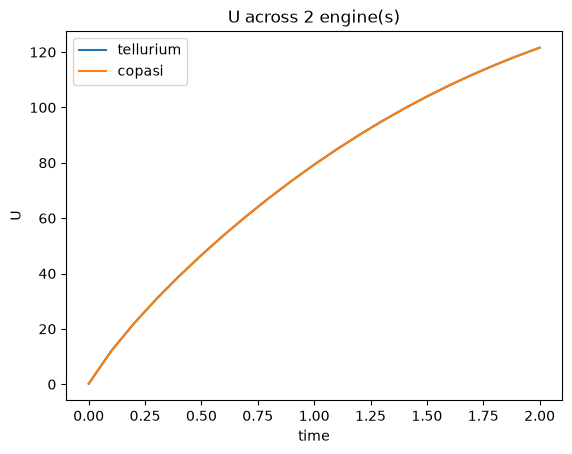

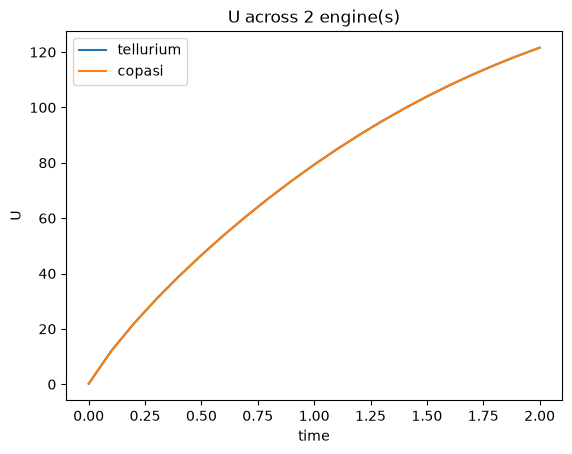

In [5]:
results = lab.compare_adapters(fitted_archive, adapters=["tellurium", "copasi"])
ax = lab.plot_comparison(results, "U")
ax.figure


## 5. Benchmark: do the two engines agree?


In [6]:
disagreement = lab.compare_trajectories(results, "U")
print(disagreement)
assert disagreement["tellurium_vs_copasi"] < 0.01, "engines should agree to within 1%"
print("Benchmarked: Tellurium and COPASI agree on the fitted model to within 1%.")


{'tellurium_vs_copasi': np.float64(2.9823050157601544e-06)}
Benchmarked: Tellurium and COPASI agree on the fitted model to within 1%.


## 6. Curate and export a lab-notebook-ready report

`curate_model` is the same mechanical gate Phase 4/6 already enforce (every
named evidence check must actually pass, and at least 2 independent
adapters must agree) — it's not a rubber stamp. `write_lab_report` then
produces one self-contained Markdown file with the fitted parameter, its
uncertainty, the curation evidence, and the cross-engine comparison: the
ELN/LIMS-friendly export Phase 11 asks for.


In [7]:
curation = lab.curate_model(
    "biomodels.db:BIOMD0000000507",
    "Gardner2000 toggle switch - refit alpha1",
    evidence_checks={
        "fit_recovers_true_value_within_95ci": p.lower_95ci < 156.25 < p.upper_95ci,
        "tellurium_and_copasi_agree_within_1pct": disagreement["tellurium_vs_copasi"] < 0.01,
    },
    adapters_used=["tellurium", "copasi"],
)

report = lab.LabReport(
    title="Toggle switch: alpha1 refit from synthetic data",
    model_curie="biomodels.db:BIOMD0000000507",
    combine_archive=fitted_archive,
    estimation=estimation,
    curation=curation,
    comparison=results,
    compared_species_id="U",
    notes=[
        "Observed data is synthetic (generated at the real published alpha1 plus 3% noise) "
        "for demonstration; a real wet-lab dataset would replace it unchanged in this workflow.",
    ],
)
report_path = lab.write_lab_report(report, "phase11_report.md")
print(report_path.read_text(encoding="utf-8"))


# Toggle switch: alpha1 refit from synthetic data

- **Model:** `biomodels.db:BIOMD0000000507`
- **Source archive:** `phase11_fitted.omex`
- **Generated:** 2026-08-20T23:04:21.180183+00:00
- **Curation tier:** curated

## Fitted parameters

Engine: `copasi` (Levenberg - Marquardt), 42 data points, objective value 0.00472694.

Confidence intervals are a Wald-type (Fisher-information) local approximation, not a full profile-likelihood scan — see `cradle.estimation.ParameterEstimate` for what that means for poorly-identified parameters.

| parameter | fitted value | 95% CI | CV |
|---|---|---|---|
| `Values[alpha1].InitialValue` | 156.119 | [155.329, 156.91] | 0.2583 |

## Cross-engine simulation comparison

| engine | final `U` value |
|---|---|
| tellurium | 121.578 |
| copasi | 121.578 |

## Curation evidence

- fit_recovers_true_value_within_95ci
- tellurium_and_copasi_agree_within_1pct

Reproduced independently on: tellurium, copasi.

## Notes

- Observed data is synthetic (generated